In [1]:
import sys
import os
from utils import get_spike_activity, sdf, sdf_mean
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as patches
import pandas as pd

with open("/home/csartor1/code/NODS/network_configuration.json", "r") as json_file:
    net_config = json.load(json_file)

CS_burst_dur = net_config["devices"]["CS"]["parameters"]["burst_dur"]
CS_start_first = float(net_config["devices"]["CS"]["parameters"]["start_first"])
between_start = net_config["devices"]["CS"]["parameters"]["between_start"]
n_trials = net_config["devices"]["CS"]["parameters"]["n_trials"]
US_start_first = float(net_config["devices"]["US"]["parameters"]["start_first"])

cell_color = net_config["cell_types"]["purkinje_cell"]["color"][0]
CS_color = net_config["colors"]["CS"]
US_color = net_config["colors"]["US"]
with_NO_color = net_config["devices"]["nNOS"]["color"][0]
without_NO_color = "#000000"
palette = list(reversed(sns.color_palette("viridis", n_trials).as_hex()))
sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(vmin=0, vmax=n_trials))

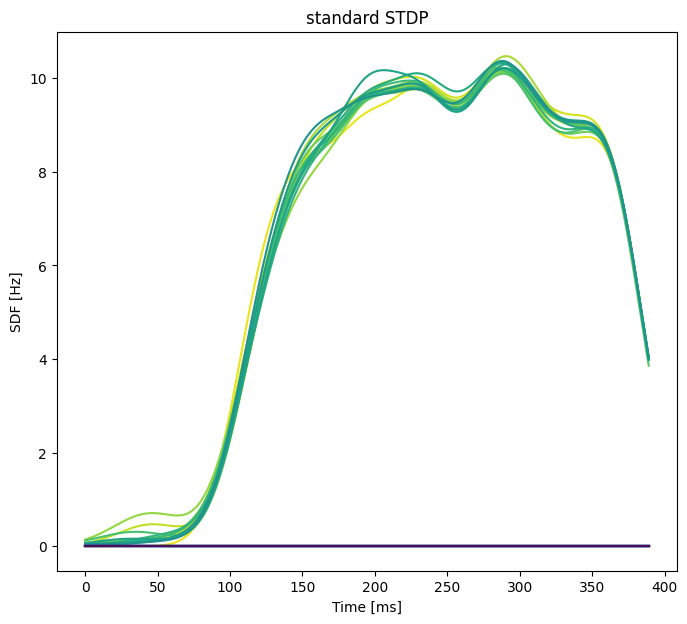

In [5]:
file_path = "/home/csartor1/code/NODS/results/grid_search/plus10_25_minus15/sim_0/"
cell = 'granule_spikes'
fig = plt.figure(figsize=(8, 7))
spk = get_spike_activity(cell_name=cell, path=file_path)

sdf_mean_cell = []

step = 5
for trial in range(n_trials):
    start = trial * between_start
    stop = CS_start_first + CS_burst_dur + trial * between_start
    
    sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
    sdf_mean_cell = sdf_mean(sdf_cell)

    plt.plot(sdf_mean_cell, palette[trial])
plt.title("standard STDP")
plt.ylabel("SDF [Hz]")
plt.xlabel("Time [ms]")

# fig_sdf.suptitle("Compare PC learning: SDF", fontsize=16)
plt.show()

In [ ]:
file_path = "/home/csartor1/code/NODS/results/test/wo_NO/0Hz/sim{k}/"
file_path_NO = folder_path_NO + f"simulation_4Hz_{k}/"

spk = get_spike_activity(cell_name=cell, path=file_path)
spk_NO = get_spike_activity(cell_name=cell, path=file_path_NO)

sdf_mean_cell = []
sdf_mean_cell_NO = []


step = 5
for trial in range(n_trials):
    start = trial * between_start
    stop = CS_start_first + CS_burst_dur + trial * between_start
    
    sdf_cell = sdf(start=start, stop=stop, spk=spk, step=step)
    sdf_mean_cell.append(sdf_mean(sdf_cell))
    
    sdf_cell_NO = sdf(start=start, stop=stop, spk=spk_NO, step=step)
    sdf_mean_cell_NO.append(sdf_mean(sdf_cell_NO))

sdf_mean_cell = np.concatenate(sdf_mean_cell)
sdf_mean_cell_NO = np.concatenate(sdf_mean_cell_NO)